In [18]:
# Cell 1 - Imports
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from wordcloud import WordCloud
print('All imports successful')

All imports successful


In [19]:
# Cell 2 - Load & Merge Datasets
with open("DATASETS/hf_jjmachan_NSFW-reddit_1778473082.json") as f:
    data1 = json.load(f)
df1 = pd.DataFrame(data1['data'])

with open("DATASETS/dataset.json") as f:
    data2 = json.load(f)
df2 = pd.DataFrame(data2['data'])

df = pd.concat([df1[['text', 'label']], df2[['text', 'label']]], ignore_index=True)
df = df.drop_duplicates(subset='text').reset_index(drop=True)
df['text_clean'] = df['text'].str.lower().str.strip()

print(df.shape)
print(df['label'].value_counts())

(552, 3)
label
clean            260
sexual           192
hate_cultural     50
threat            50
Name: count, dtype: int64


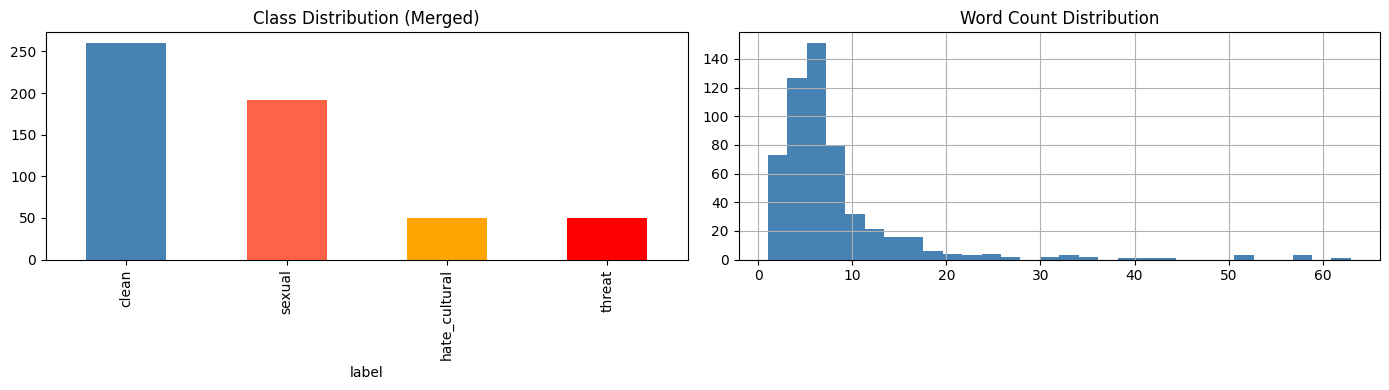

In [20]:
# Cell 3 - EDA: Class Distribution & Word Count
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['label'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue','tomato','orange','red'])
axes[0].set_title('Class Distribution (Merged)')

df['text'].str.split().str.len().hist(bins=30, ax=axes[1], color='steelblue')
axes[1].set_title('Word Count Distribution')

plt.tight_layout()
plt.show()

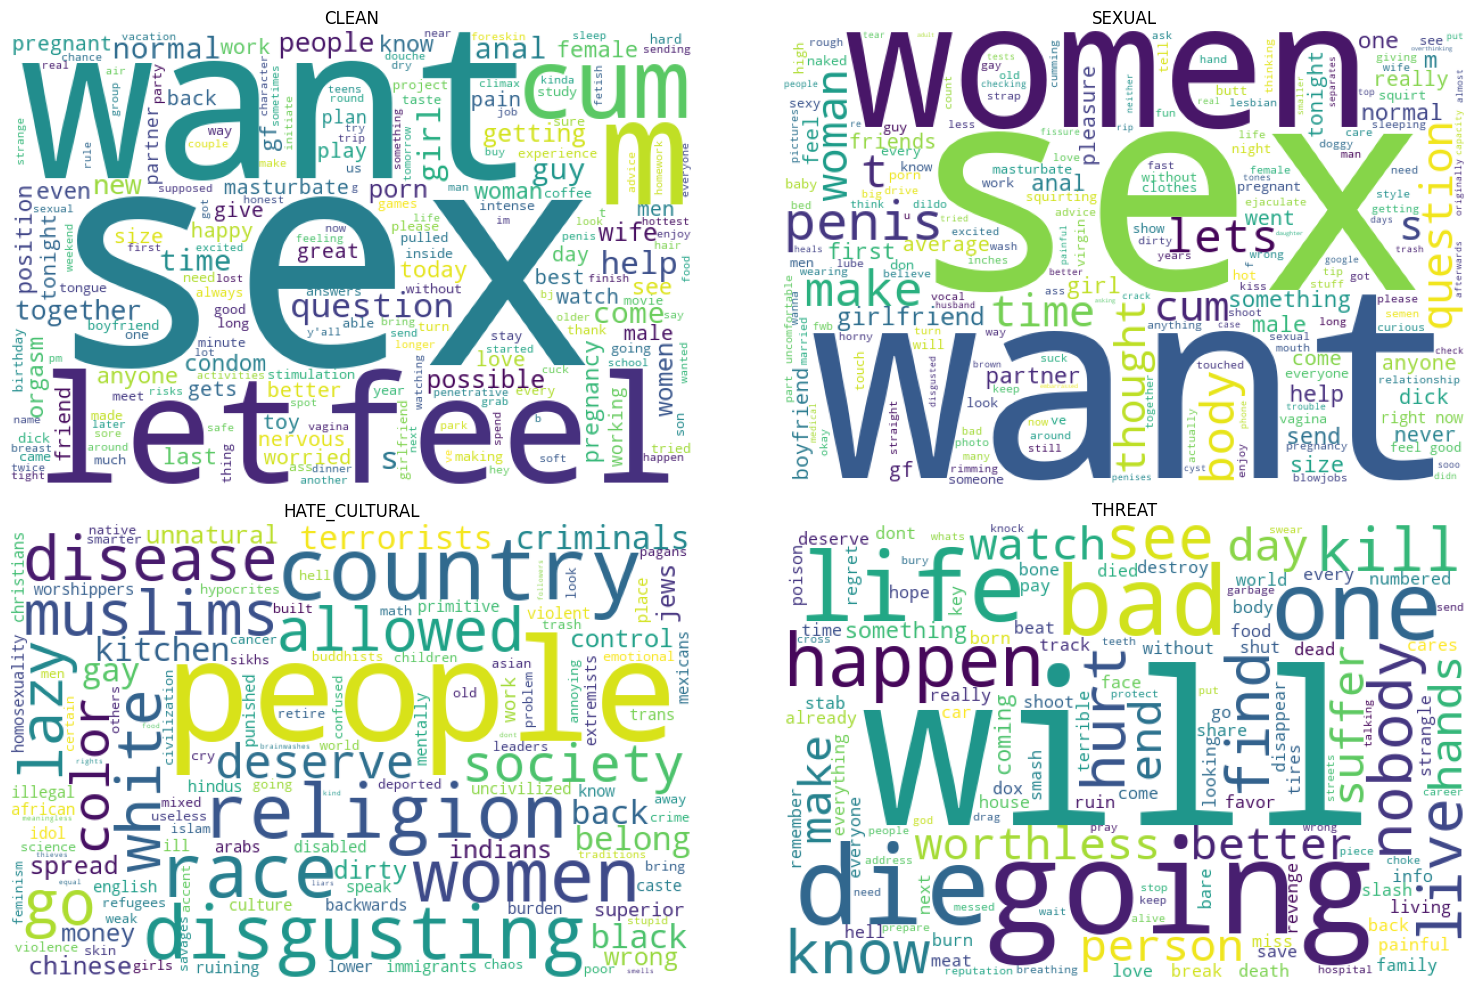

In [21]:
# Cell 4 - Wordclouds
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, label in zip(axes.flatten(), df['label'].unique()):
    text = ' '.join(df[df['label'] == label]['text_clean'])
    wc = WordCloud(width=600, height=400, background_color='white').generate(text)
    ax.imshow(wc)
    ax.set_title(f'{label.upper()}')
    ax.axis('off')

plt.tight_layout()
plt.show()

In [22]:
# Cell 5 - Encode Labels
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
print(dict(zip(le.classes_, le.transform(le.classes_))))

{'clean': np.int64(0), 'hate_cultural': np.int64(1), 'sexual': np.int64(2), 'threat': np.int64(3)}


In [23]:
# Cell 6 - Tokenize & Pad
MAX_WORDS = 8000
MAX_LEN = 50
NUM_CLASSES = len(le.classes_)

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
tokenizer.fit_on_texts(df['text_clean'])
sequences = tokenizer.texts_to_sequences(df['text_clean'])
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')
y = df['label_enc'].values

print(f'X shape: {X.shape}, Classes: {le.classes_}')

X shape: (552, 50), Classes: ['clean' 'hate_cultural' 'sexual' 'threat']


In [24]:
# Cell 7 - Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (441, 50), Test: (111, 50)


In [25]:
# Cell 8 - Build Model
model = Sequential([
    Embedding(MAX_WORDS, 64, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
# Cell 9 - Train
history = model.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.4015 - loss: 1.2742 - val_accuracy: 0.4667 - val_loss: 1.1290
Epoch 2/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4924 - loss: 1.1758 - val_accuracy: 0.4667 - val_loss: 1.1277
Epoch 3/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4419 - loss: 1.1678 - val_accuracy: 0.4667 - val_loss: 1.1182
Epoch 4/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4672 - loss: 1.1321 - val_accuracy: 0.4667 - val_loss: 1.1045
Epoch 5/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.4672 - loss: 1.0472 - val_accuracy: 0.5111 - val_loss: 0.9951
Epoch 6/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5051 - loss: 0.8659 - val_accuracy: 0.5111 - val_loss: 0.9786
Epoch 7/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5707 - loss: 0.7731 - val_accuracy: 0.4889 - val_loss: 0.9695
Epoch 8/15
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.5429 - loss: 0.8137 - val_accuracy: 0.5778 - v

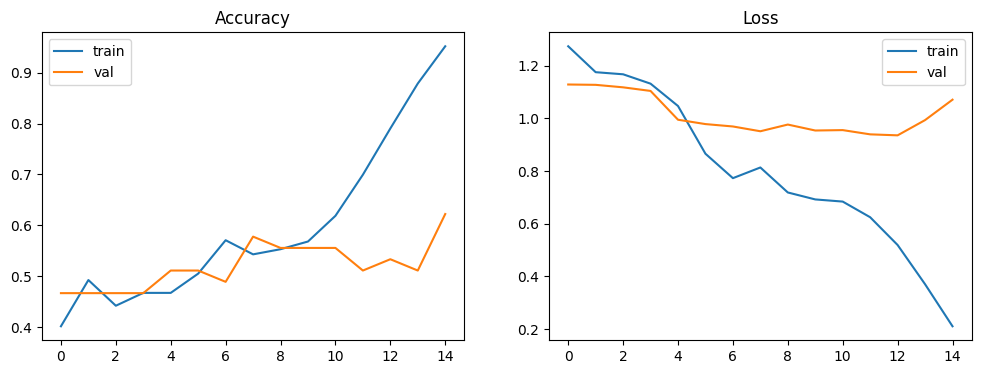

In [27]:
# Cell 10 - Training Curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='val')
axes[0].set_title('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='val')
axes[1].set_title('Loss')
axes[1].legend()
plt.show()

               precision    recall  f1-score   support

        clean       0.74      0.60      0.66        52
hate_cultural       0.67      0.40      0.50        10
       sexual       0.49      0.72      0.58        39
       threat       1.00      0.60      0.75        10

     accuracy                           0.62       111
    macro avg       0.72      0.58      0.62       111
 weighted avg       0.67      0.62      0.63       111



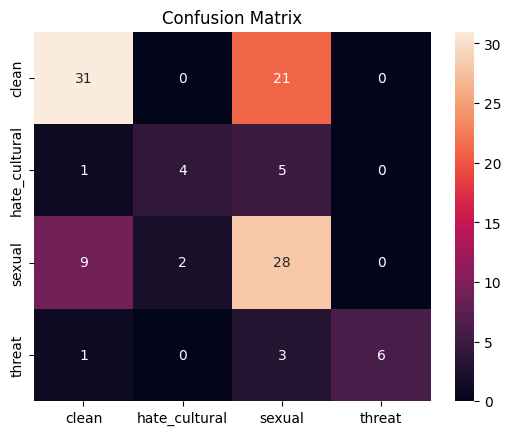

In [28]:
# Cell 11 - Evaluate
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.show()

In [29]:
# Cell 12 - Monitor Function with Keyword Override
user_violations = {}

CLEAN_PHRASES = {
    'how was your day', 'good morning', 'how are you', 'what time',
    'lets meet', 'see you', 'thank you', 'congratulations', 'happy birthday'
}

def monitor_message(user_id, message, warn_limit=2):
    msg_lower = message.lower().strip()

    # keyword override for obvious clean messages
    if any(phrase in msg_lower for phrase in CLEAN_PHRASES):
        return f"✅ Clean (override) | score: N/A"

    seq = tokenizer.texts_to_sequences([msg_lower])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    probs = model.predict(padded, verbose=0)[0]
    pred_class = le.classes_[np.argmax(probs)]
    confidence = np.max(probs)

    if pred_class == 'clean' or confidence < 0.75:
        return f"✅ Clean | class: {pred_class} | score: {confidence:.2f}"

    if user_id not in user_violations:
        user_violations[user_id] = 0
    user_violations[user_id] += 1
    count = user_violations[user_id]

    emoji = {'sexual': '🔞', 'hate_cultural': '🚨', 'threat': '⛔'}.get(pred_class, '⚠️')

    if count > warn_limit:
        return f"🚫 BLOCKED (violation #{count}) | class: {pred_class} {emoji} | score: {confidence:.2f}"
    return f"⚠️ WARNING {count}/{warn_limit} | class: {pred_class} {emoji} | score: {confidence:.2f}"

test_cases = [
    ('user_1', 'How was your day?'),
    ('user_1', 'send me your nudes'),
    ('user_1', 'all muslims are terrorists'),
    ('user_1', 'i will kill you'),
    ('user_1', 'lets grab coffee'),
    ('user_1', 'you deserve to die'),
]

for user, msg in test_cases:
    print(f"[{user}] '{msg}' → {monitor_message(user, msg)}")

[user_1] 'How was your day?' → ✅ Clean (override) | score: N/A
[user_1] 'send me your nudes' → ⚠️ WARNING 1/2 | class: sexual 🔞 | score: 0.96
[user_1] 'all muslims are terrorists' → ⚠️ WARNING 2/2 | class: hate_cultural 🚨 | score: 0.95
[user_1] 'i will kill you' → 🚫 BLOCKED (violation #3) | class: threat ⛔ | score: 0.91
[user_1] 'lets grab coffee' → ✅ Clean | class: clean | score: 0.72
[user_1] 'you deserve to die' → ✅ Clean | class: threat | score: 0.69
